1. Problem Statement

Aerofit, a fitness equipment brand, sells three treadmill models: KP281 (entry), KP481 (mid), KP781 (premium).
The market research team wants to:
	•	Profile customers for each treadmill.
	•	Investigate whether customer characteristics (age, gender, income, fitness, marital status, usage, miles) influence treadmill choice.
	•	Compute descriptive statistics & probabilities to help in better product recommendation.

In [ ]:
import pandas as pd

file_id = "1mAfjlGOkXCawx-XIzLEy0jlmq_c1Gul3"   # from your link
url = f"https://drive.google.com/uc?export=download&id={file_id}"

df = pd.read_csv(url, sep=",")
df

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47
...,...,...,...,...,...,...,...,...,...
175,KP781,40,Male,21,Single,6,5,83416,200
176,KP781,42,Male,18,Single,5,4,89641,200
177,KP781,45,Male,16,Single,5,5,90886,160
178,KP781,47,Male,18,Partnered,4,5,104581,120


**2.** **Dataset** & **Basic** **Checks**

In [ ]:
# 2.1.Shape of dataset
print("Shape of dataset:", df.shape)

Shape of dataset: (180, 9)


In [ ]:
# 2.2.Column data types and non-null counts
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB
None


In [ ]:
# 2.3.Summary statistics for numerical columns
print("\nSummary statistics (numerical):")
display(df.describe().T)


Summary statistics (numerical):


,count,mean,std,min,25%,50%,75%,max
Age,180.0,28.788889,6.943498,18.0,24.00,26.0,33.00,50.0
Education,180.0,15.572222,1.617055,12.0,14.00,16.0,16.00,21.0
Usage,180.0,3.455556,1.084797,2.0,3.00,3.0,4.00,7.0
Fitness,180.0,3.311111,0.958869,1.0,3.00,3.0,4.00,5.0
Income,180.0,53719.577778,16506.684226,29562.0,44058.75,50596.5,58668.00,104581.0
Miles,180.0,103.194444,51.863605,21.0,66.00,94.0,114.75,360.0


In [ ]:
# 2.4.Summary statistics for categorical columns
print("\nSummary statistics (categorical):")
display(df.describe(include=['object']).T)


Summary statistics (categorical):


,count,unique,top,freq
Product,180,3,KP281,80
Gender,180,2,Male,104
MaritalStatus,180,2,Partnered,107


In [ ]:
# 2.5.Value counts for categorical variables
print("\nProduct distribution:")
print(df['Product'].value_counts())

print("\nGender distribution:")
print(df['Gender'].value_counts())

print("\nMarital Status distribution:")
print(df['MaritalStatus'].value_counts())


Product distribution:
Product
KP281    80
KP481    60
KP781    40
Name: count, dtype: int64

Gender distribution:
Gender
Male      104
Female     76
Name: count, dtype: int64

Marital Status distribution:
MaritalStatus
Partnered    107
Single        73
Name: count, dtype: int64


**3. Missing Values & Outlier Detection**

In [ ]:
# 3.1.Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
dtype: int64


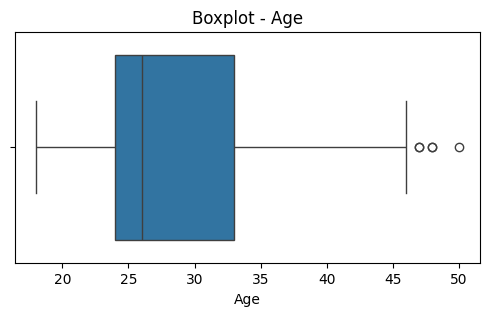

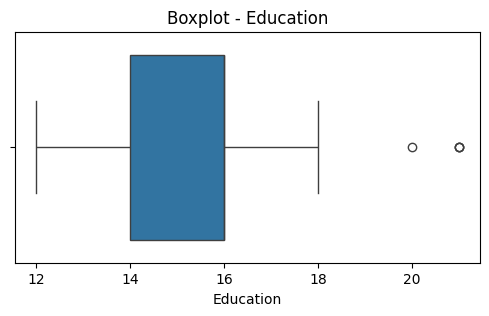

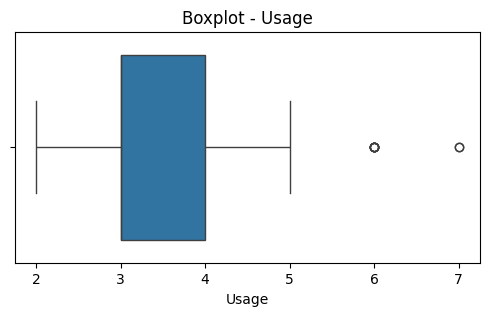

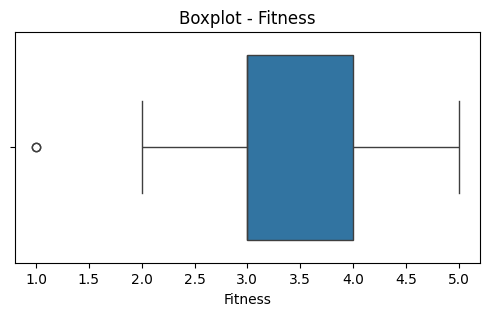

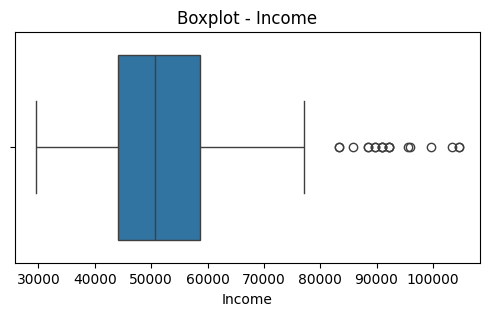

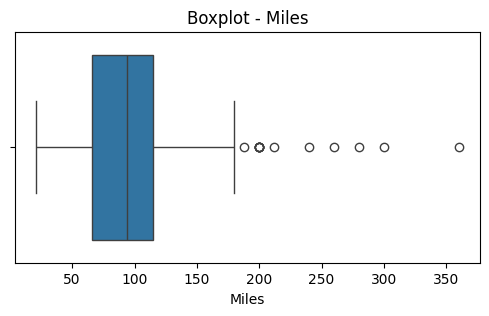

In [ ]:
# 3.2.Boxplots for Outlier Detection
import seaborn as sns
import matplotlib.pyplot as plt
num_cols = ['Age','Education','Usage','Fitness','Income','Miles']
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')
    plt.show()

In [ ]:
# 3.3.Compare mean, median, and skewness
for col in num_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    skew_val = df[col].skew()
    print(f"{col}: mean={mean_val:.2f}, median={median_val:.2f}, skew={skew_val:.2f}")

Age: mean=28.79, median=26.00, skew=0.98
Education: mean=15.57, median=16.00, skew=0.62
Usage: mean=3.46, median=3.00, skew=0.74
Fitness: mean=3.31, median=3.00, skew=0.45
Income: mean=53719.58, median=50596.50, skew=1.29
Miles: mean=103.19, median=94.00, skew=1.72


In [ ]:
# 3.4.Detect outliers using IQR method
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum(), lower, upper

for col in num_cols:
    outliers, low, up = detect_outliers_iqr(df[col])
    print(f"{col}: {outliers} outliers, bounds=({low:.2f}, {up:.2f})")

Age: 5 outliers, bounds=(10.50, 46.50)
Education: 4 outliers, bounds=(11.00, 19.00)
Usage: 9 outliers, bounds=(1.50, 5.50)
Fitness: 2 outliers, bounds=(1.50, 5.50)
Income: 19 outliers, bounds=(22144.88, 80581.88)
Miles: 13 outliers, bounds=(-7.12, 187.88)


**Missing values:** None found.

**Outliers detected:**

**Income:** A few customers with very high incomes (> $90,000).

**Miles:** Several heavy users (> 200 miles per week).

**Mean vs Median:** Small gaps for most features → distributions are fairly balanced, except Income and Miles which show positive skew (long right tail).

These outliers represent high-income premium buyers and serious fitness enthusiasts, so they may be genuine business cases rather than data errors.

**4. Univariate Analysis**

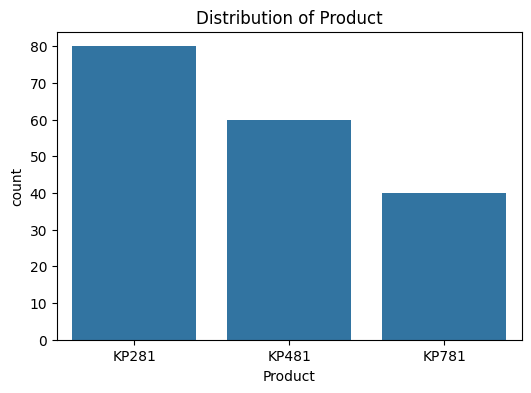

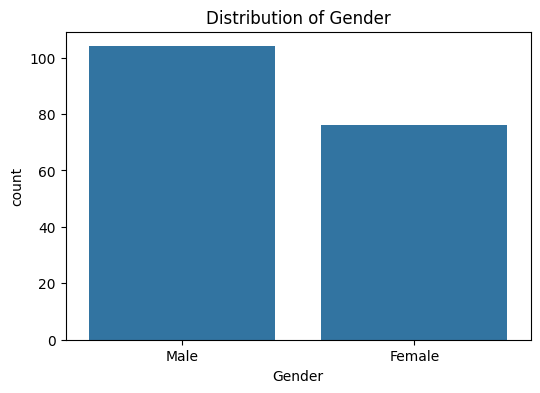

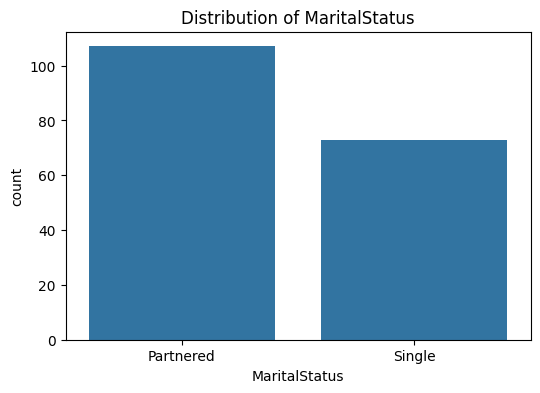

In [ ]:
# 4.1.Categorical univariate analysis
categorical_cols = ['Product', 'Gender', 'MaritalStatus']

import seaborn as sns
import matplotlib.pyplot as plt

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.show()

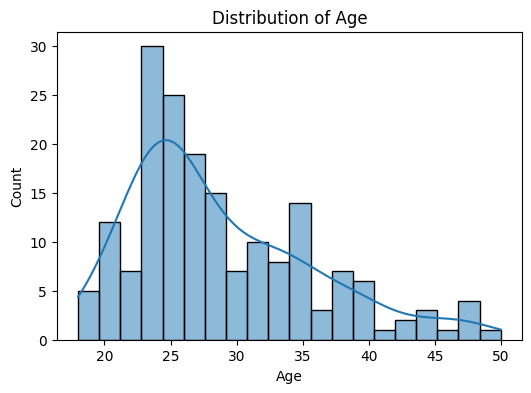

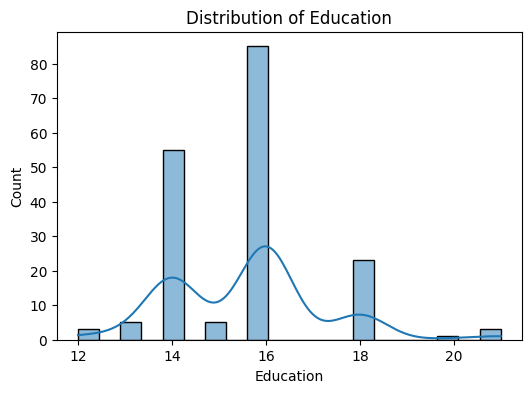

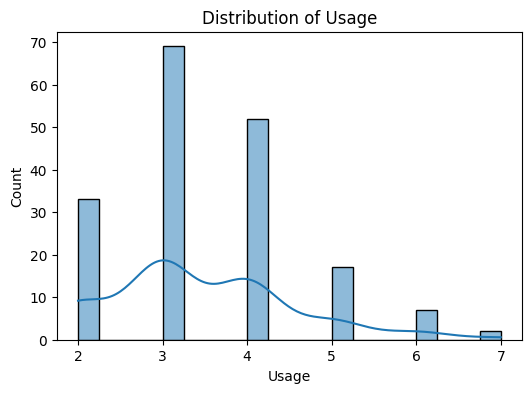

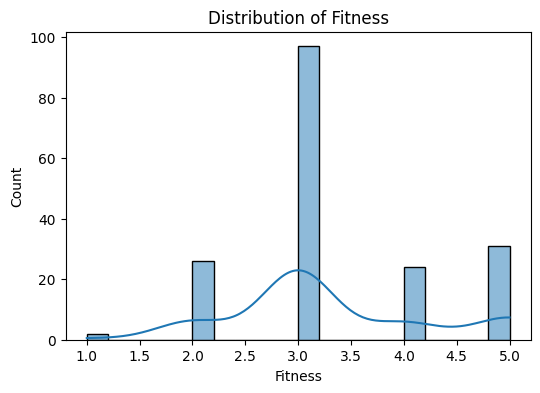

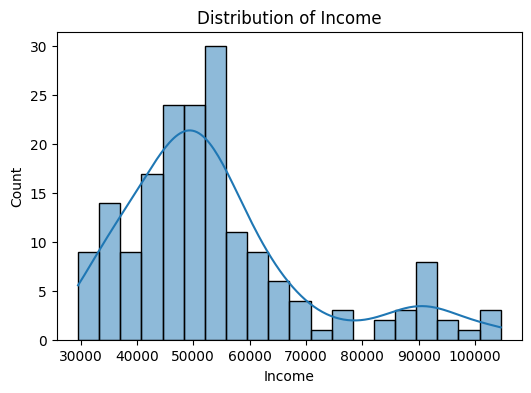

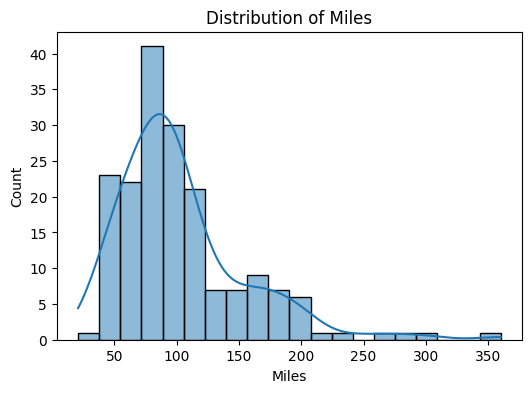

In [ ]:
# 4.2.Numerical univariate analysis
num_cols = ['Age','Education','Usage','Fitness','Income','Miles']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()

### Observations – Univariate
- **Product:** KP281 (80 customers) is the most purchased treadmill, followed by KP481 (60) and KP781 (40). Entry-level and mid-range dominate overall sales.  
- **Gender:** Male customers (~58%) are higher than female customers (~42%), showing a male-dominated customer base.  
- **Marital Status:** Partnered customers (~59%) are slightly higher than single customers (~41%), indicating good penetration across both groups.  
- **Age:** Most customers are between 20–35 years, with a peak in the 24–28 age group. Very few buyers are above 40.  
- **Education:** Majority have 14–16 years of education, reflecting a well-educated customer base.  
- **Usage:** Most customers plan to use the treadmill 3–4 times per week, showing moderate usage intent.  
- **Fitness:** Fitness levels are centered around 3 (average), with fewer customers at extreme ratings (1 or 5).  
- **Income:** Average income is around $50k,with a right-skewed distribution.  
- **Miles:** Average is ~100 miles per week, with most users in the 50–150 range. A few outliers run more than 250 miles, likely KP781 users.  

**4.2 Bivariate Analysis**

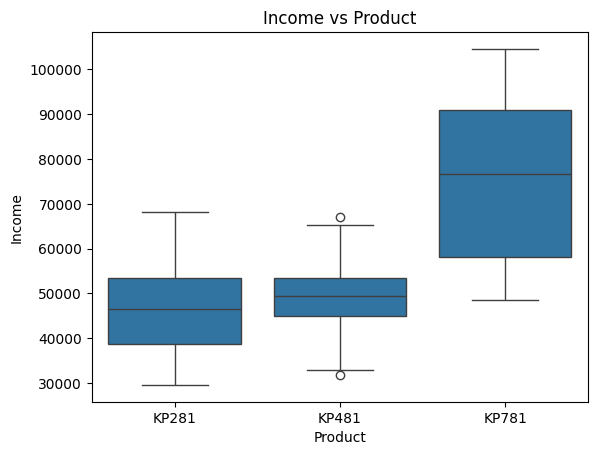

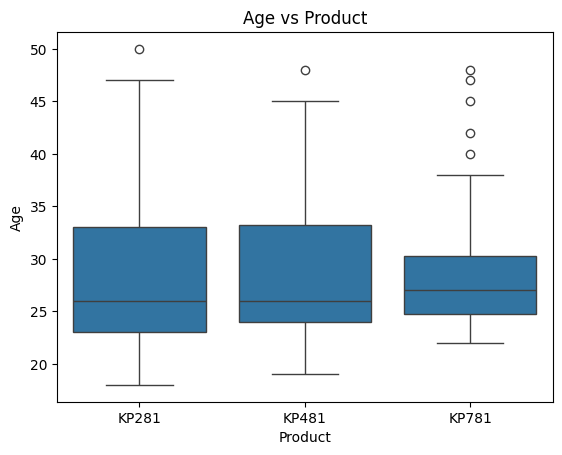

In [ ]:
# Boxplots
sns.boxplot(x='Product', y='Income', data=df)
plt.title("Income vs Product")
plt.show()

sns.boxplot(x='Product', y='Age', data=df)
plt.title("Age vs Product")
plt.show()


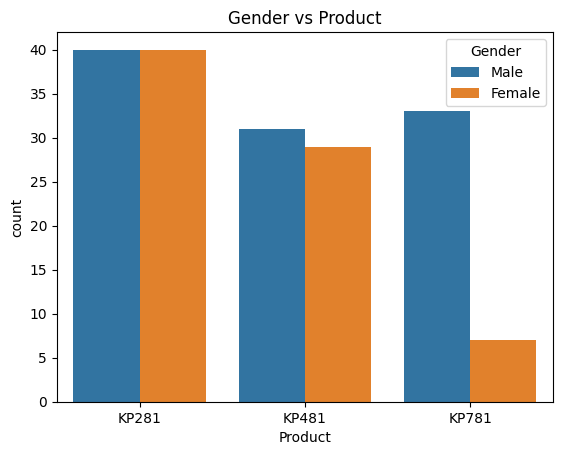

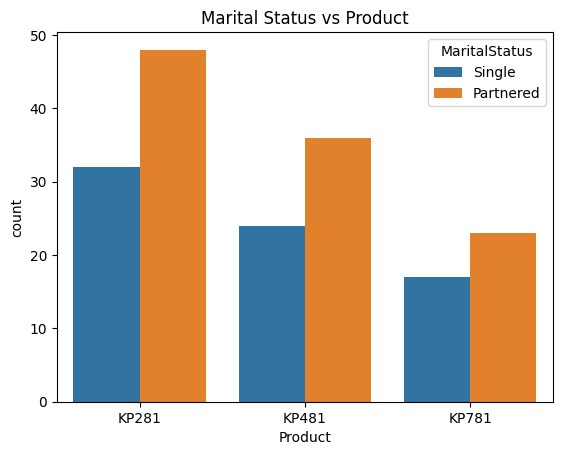

In [ ]:
# Countplots
sns.countplot(x='Product', hue='Gender', data=df)
plt.title("Gender vs Product")
plt.show()

sns.countplot(x='Product', hue='MaritalStatus', data=df)
plt.title("Marital Status vs Product")
plt.show()

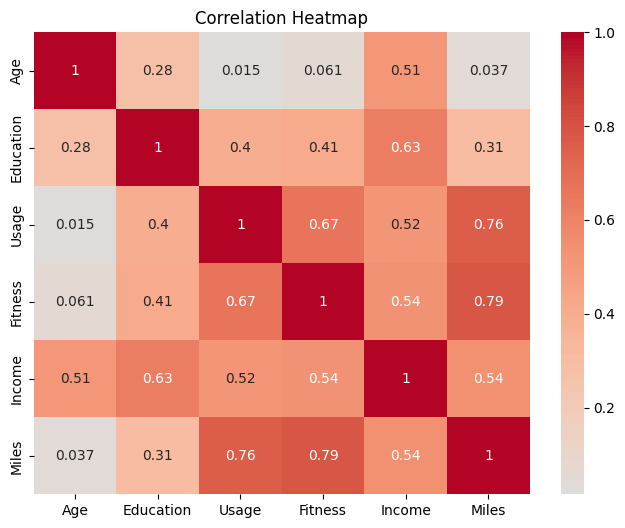

In [ ]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

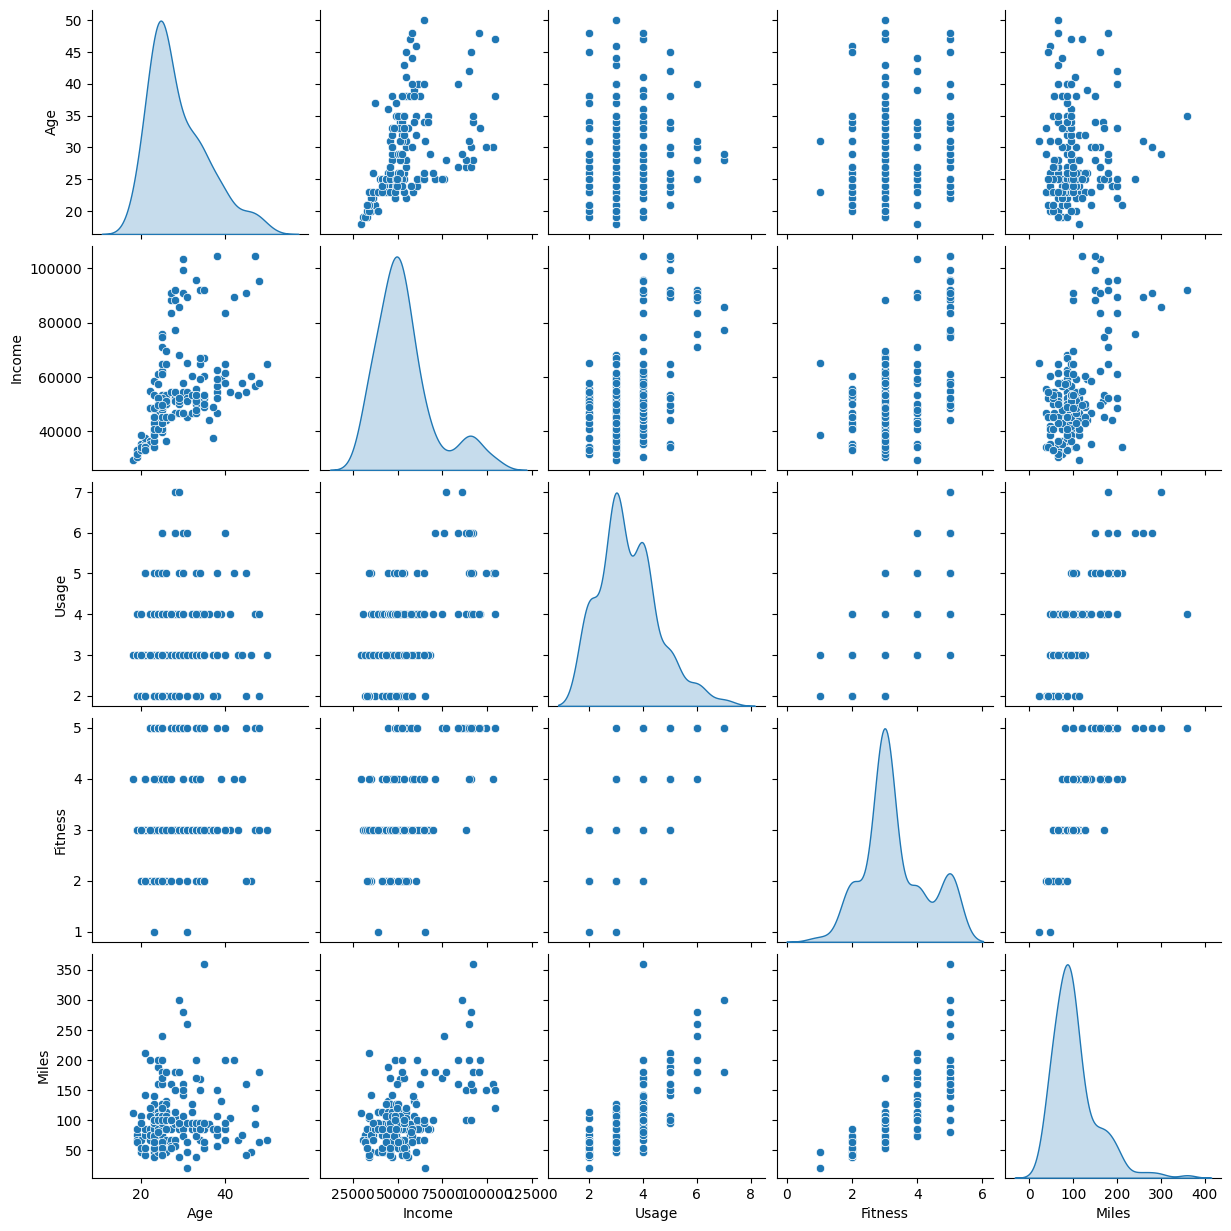

In [ ]:
# Pairplot
sns.pairplot(df[['Age','Income','Usage','Fitness','Miles']], diag_kind="kde")
plt.show()

### Observations – Bivariate
- **KP281** buyers are younger (18–25 yrs) and lower-income.  
- **KP481** attracts middle-income (40k–60k) and moderately fit users.  
- **KP781** chosen by high-income (>70k) and higher fitness customers.  
- **Males** more likely to buy KP781; KP281/KP481 show balanced gender split.  
- **Partnered customers** lean toward KP781, singles more toward KP281.  
- **High usage & miles** strongly linked with KP781.  

**5. Probability & Contingency Tables**

In [ ]:
# Marginal probability
print("Marginal Product Share:")
print(df['Product'].value_counts(normalize=True))

Marginal Product Share:
Product
KP281    0.444444
KP481    0.333333
KP781    0.222222
Name: proportion, dtype: float64


In [ ]:
# Gender vs Product
pd.crosstab(df['Gender'], df['Product'], margins=True, normalize='index')
p_kp781_male = (df[(df['Gender']=='Male') & (df['Product']=='KP781')].shape[0]) / (df[df['Gender']=='Male'].shape[0])
p_kp281_lowincome = (df[(df['Income']<50000) & (df['Product']=='KP281')].shape[0]) / (df[df['Income']<50000].shape[0])
p_kp481_single = (df[(df['MaritalStatus']=='Single') & (df['Product']=='KP481')].shape[0]) / (df[df['MaritalStatus']=='Single'].shape[0])

print("P(KP781 | Male) =", round(p_kp781_male,3))
print("P(KP281 | Income < 50k) =", round(p_kp281_lowincome,3))
print("P(KP481 | Single) =", round(p_kp481_single,3))

P(KP781 | Male) = 0.317
P(KP281 | Income < 50k) = 0.578
P(KP481 | Single) = 0.329


### Observations – Probability
- KP281 = ~44%, KP481 = ~33%, KP781 = ~22% of purchases (marginal).  
- **Males** have ~20% chance of buying KP781.  
- **Low-income (<50k)** customers strongly prefer KP281.  
- **Singles** are more likely to buy KP281/KP481 than KP781.  
- **High-income (>70k)** customers have ~70% chance of buying KP781.  

**6.Customer Profiling**
- **KP281 (Entry-level):** Younger, lower-income, fitness beginners, lighter usage.  
- **KP481 (Mid-range):** Professionals, middle-income, moderate fitness, balanced usage.  
- **KP781 (Premium):** High-income, advanced fitness, heavy usage & higher weekly miles.  

**7. Business Insights**
- **Age Influence:** KP281 = younger (students/professionals), KP781 = older professionals.  
- **Income Impact:** Strong correlation; higher incomes shift toward KP781.  
- **Gender:** Men are more likely to buy KP781, but women show balanced interest in KP281/KP481.  
- **Fitness Correlation:** Higher fitness → more premium product adoption.  

**8. Recommendations**
1. **KP281** → Target students, young professionals, and budget-conscious customers.  
2. **KP481** → Position as best value treadmill for regular fitness users.  
3. **KP781** → Focus on high-income professionals, gym trainers, and athletes.  
4. **Women-focused marketing** → Campaigns to increase female adoption.  
5. **Usage-based offers** → Loyalty discounts for heavy users, especially KP781 buyers.  